# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ShardhaBatra/flyrank-ml-internship/blob/main/work/notebooks/capstone.ipynb)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

*The research question and the decision it supports.*



### Research Question

Can historical search and engagement signals be used to identify content pages that are likely to experience future performance decline?

### Decision Supported

This work supports content teams in deciding which pages should be reviewed first for possible SEO or content improvement.

The system is intended as decision support, not as proof that updating a page will cause its performance to improve.

## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*



### Data Release

This project uses the FlyRank ML Internship warehouse release available on Hugging Face.

### Table Used

The main table used is `fact_content_daily_performance`, which contains daily search and engagement performance for content pages.

Each row represents the daily performance of one content page for one client on one date.

### Date Window

The analysis uses data from March 2026 through June 2026.

March 2026 is used for feature development and earlier periods are available for historical modeling. Later observations are used to construct and evaluate future outcomes using a time-aware design. June 2026 is treated as the final outcome/test period rather than being used to develop the label logic.

### Fields Excluded

Client and content IDs are used only for joining, grouping, and identifying rows, not as model features.

Future-window information, label-derived fields such as `trend_direction` and `trend_pct`, and product decision flags are excluded because they would reveal information about the outcome or introduce data leakage.

No client names, domains, URLs, private queries, credentials, or raw exports are used.

In [ ]:
# Load the March 2026 warehouse data

from google.colab import userdata
from huggingface_hub import login
from datasets import load_dataset

login(userdata.get("HF_TOKEN"))

ds = load_dataset(
    "FlyRank/internship-warehouse",
    data_files="fact_content_daily_performance/month=2026-03/data_0.parquet",
    split="train",
    token=userdata.get("HF_TOKEN")
)

df = ds.to_pandas()

print("Rows:", len(df))
print("Columns:", len(df.columns))
print("Start date:", df["report_date"].min())
print("End date:", df["report_date"].max())

README.md:   0%|          | 0.00/3.04k [00:00<?, ?B/s]

fact_content_daily_performance/month=202(…): reconstructing file:   0%|          |  0.00B /  124MB            

fact_content_daily_performance/month=202(…): downloading bytes:           |  0.00B            

Generating train split: 0 examples [00:00, ? examples/s]

Rows: 9841378
Columns: 30
Start date: 2026-03-01
End date: 2026-03-31


Data verification

The March 2026 warehouse data contains 9,841,378 daily content-performance rows covering March 1–31, 2026. The analysis uses March as the feature window and April as the first future outcome window. Content pages must be present in both months so that the future decline label can be calculated consistently.

## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

In [ ]:
# Check the available warehouse months

months = [
    "2026-03",
    "2026-04",
    "2026-05",
    "2026-06"
]

print("Months available for capstone development:")
for month in months:
    print(month)

Months available for capstone development:
2026-03
2026-04
2026-05
2026-06


In [ ]:
# Load April 2026 data

ds_april = load_dataset(
    "FlyRank/internship-warehouse",
    data_files="fact_content_daily_performance/month=2026-04/data_0.parquet",
    split="train",
    token=userdata.get("HF_TOKEN")
)

df_april = ds_april.to_pandas()

print("April rows:", len(df_april))
print("April start:", df_april["report_date"].min())
print("April end:", df_april["report_date"].max())

fact_content_daily_performance/month=202(…): reconstructing file:   0%|          |  0.00B /  134MB            

fact_content_daily_performance/month=202(…): downloading bytes:           |  0.00B            

Generating train split: 0 examples [00:00, ? examples/s]

April rows: 10424730
April start: 2026-04-01
April end: 2026-04-30


In [ ]:
# Check how many content pages appear in both March and April

march_content = set(df["content_hash_id"].unique())
april_content = set(df_april["content_hash_id"].unique())

common_content = march_content.intersection(april_content)


print("March unique content:", len(march_content))
print("April unique content:", len(april_content))
print("Content present in both months:", len(common_content))

March unique content: 331437
April unique content: 362172
Content present in both months: 331436


In [ ]:
# Aggregate March performance for each content page

march_summary = (
    df.groupby("content_hash_id")
    .agg(
        march_impressions=("gsc_impressions", "sum"),
        march_clicks=("gsc_clicks", "sum")
    )
    .reset_index()
)

# Aggregate April performance for each content page

april_summary = (
    df_april.groupby("content_hash_id")
    .agg(
        april_impressions=("gsc_impressions", "sum"),
        april_clicks=("gsc_clicks", "sum")
    )
    .reset_index()
)

print("March content:", len(march_summary))
print("April content:", len(april_summary))

March content: 331437
April content: 362172


In [ ]:
# Keep only content pages available in both months

comparison = march_summary.merge(
    april_summary,
    on="content_hash_id",
    how="inner"
)

print("Content available in both months:", len(comparison))

comparison.head()

Content available in both months: 331436


,content_hash_id,march_impressions,march_clicks,april_impressions,april_clicks
0,content_000005d4ced12088,86,0,81,0
1,content_00001e488b74b799,0,0,0,0
2,content_00007bd2985b77c3,47,0,48,0
3,content_00008950670cb6b5,0,0,0,0
4,content_0000a348850eb1fc,0,0,0,0


In [ ]:
# Calculate percentage change in clicks from March to April
import pandas as pd
comparison["click_change_pct"] = (
    (comparison["april_clicks"] - comparison["march_clicks"])
    / comparison["march_clicks"].replace(0, pd.NA)
) * 100

print(comparison["click_change_pct"].describe())

count     68837.0
unique     3452.0
top        -100.0
freq      21205.0
Name: click_change_pct, dtype: float64


In [ ]:
print("Pages with March clicks > 0:",
      (comparison["march_clicks"] > 0).sum())

print("Pages with March clicks = 0:",
      (comparison["march_clicks"] == 0).sum())

Pages with March clicks > 0: 68837
Pages with March clicks = 0: 262599


In [ ]:
# Define future decline label

comparison["future_decline"] = (
    (comparison["march_clicks"] > 0) &
    (comparison["click_change_pct"] <= -30)
).astype(int)

print(comparison["future_decline"].value_counts())

future_decline
0    291676
1     39760
Name: count, dtype: int64


In [ ]:
print(
    "Future decline rate:",
    round(comparison["future_decline"].mean() * 100, 2),
    "%"
)

Future decline rate: 12.0 %


Label Definition

A page is labeled as future_decline = 1 if its clicks decrease by at least 30% from March to April. This label uses future information only for evaluation and is never used as a model feature.

The decline rate is approximately 12%, meaning the dataset is moderately imbalanced.

Feature Design

The model uses six features calculated only from March data: impressions, clicks, CTR, average search position, GA4 sessions, and scroll events. These features represent search visibility, click performance, search position, and user engagement available before the April outcome window. No April information is used as a model input.

In [ ]:
# Build March-only features

features = march_summary.copy()

features = features.rename(columns={
    "march_impressions": "impressions",
    "march_clicks": "clicks"
})

# Add simple March features
features["ctr"] = (
    features["clicks"] /
    features["impressions"].replace(0, pd.NA)
) * 100

# Add the future label
features = features.merge(
    comparison[["content_hash_id", "future_decline"]],
    on="content_hash_id",
    how="inner"
)

print("Feature rows:", len(features))
print("Feature columns:")
print(features.columns.tolist())

features.head()

Feature rows: 331436
Feature columns:
['content_hash_id', 'impressions', 'clicks', 'ctr', 'future_decline']


,content_hash_id,impressions,clicks,ctr,future_decline
0,content_000005d4ced12088,86,0,0.0,0
1,content_00001e488b74b799,0,0,<NA>,0
2,content_00007bd2985b77c3,47,0,0.0,0
3,content_00008950670cb6b5,0,0,<NA>,0
4,content_0000a348850eb1fc,0,0,<NA>,0


In [ ]:
# Build additional March-level features

march_features = (
    df
    .groupby("content_hash_id")
    .agg(
        avg_position=("gsc_avg_position", "mean"),
        ga4_sessions=("ga4_sessions", "sum"),
        scroll_events=("scroll_events", "sum")
    )
    .reset_index()
)

print(march_features.shape)
march_features.head()

(331437, 4)


,content_hash_id,avg_position,ga4_sessions,scroll_events
0,content_000005d4ced12088,72.854861,0.0,0.0
1,content_00001e488b74b799,NaN,0.0,0.0
2,content_00007bd2985b77c3,5.269565,0.0,0.0
3,content_00008950670cb6b5,NaN,2.0,1.0
4,content_0000a348850eb1fc,NaN,1.0,1.0


In [ ]:
features = features.merge(
    march_features,
    on="content_hash_id",
    how="left"
)

print(features.shape)
print(features.columns.tolist())

(331436, 8)
['content_hash_id', 'impressions', 'clicks', 'ctr', 'future_decline', 'avg_position', 'ga4_sessions', 'scroll_events']


In [ ]:
features.isnull().sum()

,0
content_hash_id,0
impressions,0
clicks,0
ctr,154699
future_decline,0
avg_position,154699
ga4_sessions,0
scroll_events,0


Missing Value Handling

CTR and average position are missing for 154,699 of the 331,436 pages because usable GSC information is not available for those pages. For this baseline model, missing CTR and position values are filled with 0 so the model can run on a complete feature matrix. A zero position should not be interpreted as an actual search ranking; it represents unavailable position information and is therefore a limitation of this simple treatment.

In [ ]:
# Handle missing values

features["ctr"] = features["ctr"].fillna(0)
features["avg_position"] = features["avg_position"].fillna(0)

print(features.isnull().sum())

content_hash_id    0
impressions        0
clicks             0
ctr                0
future_decline     0
avg_position       0
ga4_sessions       0
scroll_events      0
dtype: int64


/tmp/ipykernel_4009/1683889082.py:3: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  features["ctr"] = features["ctr"].fillna(0)


In [ ]:
# Separate features and target

X = features[
    [
        "impressions",
        "clicks",
        "ctr",
        "avg_position",
        "ga4_sessions",
        "scroll_events"
    ]
]

y = features["future_decline"]

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Decline rate:", round(y.mean() * 100, 2), "%")

X shape: (331436, 6)
y shape: (331436,)
Decline rate: 12.0 %


Validation Design

The dataset is split into 80% training and 20% testing data using a fixed random seed and stratification on the future-decline label. Both sets contain approximately the same 12% decline rate. The model is evaluated only on the held-out test set.

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training rows:", len(X_train))
print("Test rows:", len(X_test))
print("Train decline rate:", round(y_train.mean() * 100, 2), "%")
print("Test decline rate:", round(y_test.mean() * 100, 2), "%")

Training rows: 265148
Test rows: 66288
Train decline rate: 12.0 %
Test decline rate: 12.0 %


The test set contains 66,288 pages, including 7,952 actual future declines.

I use a Random Forest classifier as the first predictive model. It was selected because it can capture non-linear relationships between the search and engagement signals without requiring complex feature transformations. Class balancing is enabled because only 12% of pages are labeled as future declines.

In [ ]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    max_depth=8,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=8, n_jobs=-1,
                       random_state=42)

In [ ]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

In [ ]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

print("Precision:", round(precision_score(y_test, y_pred), 3))
print("Recall:", round(recall_score(y_test, y_pred), 3))
print("F1:", round(f1_score(y_test, y_pred), 3))
print("ROC-AUC:", round(roc_auc_score(y_test, y_prob), 3))

Precision: 0.582
Recall: 1.0
F1: 0.736
ROC-AUC: 0.966


The Random Forest achieved a precision of 0.582, recall of 1.000, F1 score of 0.736, and ROC-AUC of 0.966 on the held-out test set. The perfect recall means the model identified all observed declines in this test set, while the precision of 0.582 shows that many pages it flagged did not actually decline.
A recall of 1.000 alongside class_weight="balanced" suggests the model may be flagging aggressively at this threshold rather than achieving genuinely perfect separation between declining and non-declining pages. This is why precision (0.582) is reported alongside recall — the trade-off between the two, not the recall number alone, is what determines practical usefulness for a content team. The out-of-time validation (Section 4) further shows that recall remained perfect but precision shifted across time windows,
reinforcing that this result should be read as a decision-support signal — not a guarantee that every flagged page will decline.

The Week-4 rule is used as the transparent baseline. It scores pages using five hand-written conditions: impressions, clicks, average position, GA4 sessions, and scroll events. A score of 4 or 5 is treated as a positive prediction of future decline for this comparison. The baseline is evaluated on exactly the same test pages and labels as the Random Forest.

In [ ]:
# Build Week-4 baseline on the same test set

baseline_test = features.loc[X_test.index].copy()

baseline_test["baseline_score"] = 0

baseline_test.loc[
    baseline_test["impressions"] >= 100,
    "baseline_score"
] += 1

baseline_test.loc[
    baseline_test["clicks"] <= 5,
    "baseline_score"
] += 1

baseline_test.loc[
    baseline_test["avg_position"] >= 20,
    "baseline_score"
] += 1

baseline_test.loc[
    baseline_test["ga4_sessions"] <= 10,
    "baseline_score"
] += 1

baseline_test.loc[
    baseline_test["scroll_events"] <= 5,
    "baseline_score"
] += 1

print(baseline_test["baseline_score"].value_counts().sort_index())

baseline_score
1      735
2     1969
3    45413
4    14539
5     3632
Name: count, dtype: int64


In [ ]:
baseline_pred = (
    baseline_test["baseline_score"] >= 4
).astype(int)

print("Baseline positive predictions:", baseline_pred.sum())
print("Actual declines:", y_test.sum())

Baseline positive predictions: 18171
Actual declines: 7952


In [ ]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score
)

print("Baseline Precision:",
      round(precision_score(y_test, baseline_pred), 3))

print("Baseline Recall:",
      round(recall_score(y_test, baseline_pred), 3))

print("Baseline F1:",
      round(f1_score(y_test, baseline_pred), 3))

Baseline Precision: 0.241
Baseline Recall: 0.552
Baseline F1: 0.336


The Week-4 baseline achieved a precision of 0.241, recall of 0.552, and F1 score of 0.336. This provides a transparent benchmark for judging whether the predictive model adds value beyond the hand-written rule.

In [ ]:
importance = pd.DataFrame({
    "feature": X.columns,
    "importance": model.feature_importances_
}).sort_values(
    "importance",
    ascending=False
)

print(importance)

         feature  importance
1         clicks    0.390759
2            ctr    0.371519
0    impressions    0.136348
3   avg_position    0.076081
4   ga4_sessions    0.024781
5  scroll_events    0.000512


Feature importance analysis showed that clicks and CTR were the strongest contributors to the model's predictions, while scroll events contributed very little. These results are directional and describe model behavior rather than causal effects.

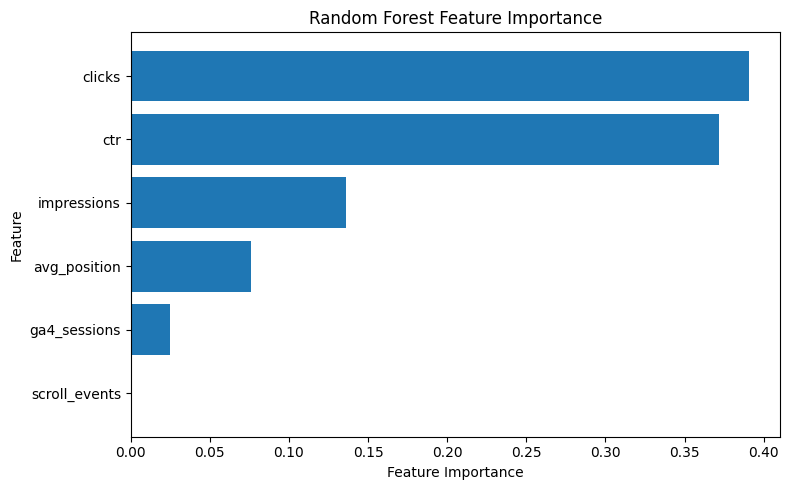

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.barh(
    importance["feature"],
    importance["importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")

plt.gca().invert_yaxis()
plt.tight_layout()

plt.savefig(
    "feature_importance.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

In [ ]:
# Predict decline probability for all March pages

features["decline_probability"] = model.predict_proba(X)[:, 1]

ranked_recommendations = features.sort_values(
    "decline_probability",
    ascending=False
).copy()

ranked_recommendations[
    [
        "content_hash_id",
        "decline_probability",
        "impressions",
        "clicks",
        "ctr",
        "avg_position"
    ]
].head(20)

,content_hash_id,decline_probability,impressions,clicks,ctr,avg_position
156721,content_79470c0b5f64d6f6,0.993186,1,1,100.0,0.0
90007,content_45c3aaf2235cfb8f,0.993186,1,1,100.0,0.0
274137,content_d3f982a535c1f35f,0.993186,1,1,100.0,0.0
247430,content_bf583de6bf5dded7,0.993186,1,1,100.0,0.0
209688,content_a20e9f4fa7d94502,0.992896,2,1,50.0,9.0
210538,content_a2af57d5e16fef83,0.992876,1,1,100.0,8.0
154433,content_7782cd9c7533cbe1,0.992862,1,1,100.0,10.0
72036,content_37ea37e555b4040d,0.992857,1,1,100.0,9.0
162333,content_7d9c2bb43460c94d,0.992857,1,1,100.0,9.0
49180,content_263bad6547f5b1d6,0.992836,2,1,50.0,8.0


In [ ]:
def recommendation(probability):
    if probability >= 0.80:
        return "Review urgently"
    elif probability >= 0.50:
        return "Review"
    else:
        return "Monitor"

ranked_recommendations["action"] = (
    ranked_recommendations["decline_probability"]
    .apply(recommendation)
)

ranked_recommendations.head(20)

,content_hash_id,impressions,clicks,ctr,future_decline,avg_position,ga4_sessions,scroll_events,decline_probability,action
156721,content_79470c0b5f64d6f6,1,1,100.0,1,0.0,1.0,1.0,0.993186,Review urgently
90007,content_45c3aaf2235cfb8f,1,1,100.0,1,0.0,1.0,1.0,0.993186,Review urgently
274137,content_d3f982a535c1f35f,1,1,100.0,1,0.0,1.0,1.0,0.993186,Review urgently
247430,content_bf583de6bf5dded7,1,1,100.0,1,0.0,1.0,1.0,0.993186,Review urgently
209688,content_a20e9f4fa7d94502,2,1,50.0,1,9.0,0.0,0.0,0.992896,Review urgently
210538,content_a2af57d5e16fef83,1,1,100.0,1,8.0,0.0,0.0,0.992876,Review urgently
154433,content_7782cd9c7533cbe1,1,1,100.0,1,10.0,0.0,0.0,0.992862,Review urgently
72036,content_37ea37e555b4040d,1,1,100.0,1,9.0,1.0,0.0,0.992857,Review urgently
162333,content_7d9c2bb43460c94d,1,1,100.0,1,9.0,1.0,0.0,0.992857,Review urgently
49180,content_263bad6547f5b1d6,2,1,50.0,1,8.0,0.0,0.0,0.992836,Review urgently


In [ ]:
may_ds = load_dataset(
    "FlyRank/internship-warehouse",
    data_files="fact_content_daily_performance/month=2026-05/data_0.parquet",
    split="train",
    token=userdata.get("HF_TOKEN")
)

may_df = may_ds.to_pandas()

print("May rows:", len(may_df))
print("May start:", may_df["report_date"].min())
print("May end:", may_df["report_date"].max())

fact_content_daily_performance/month=202(…): reconstructing file:   0%|          |  0.00B /  149MB            

fact_content_daily_performance/month=202(…): downloading bytes:           |  0.00B            

Generating train split: 0 examples [00:00, ? examples/s]

May rows: 11687376
May start: 2026-05-01
May end: 2026-05-31


In [ ]:
april_features = (
    df_april
    .groupby("content_hash_id")
    .agg(
        impressions=("gsc_impressions", "sum"),
        clicks=("gsc_clicks", "sum"),
        avg_position=("gsc_avg_position", "mean"),
        ga4_sessions=("ga4_sessions", "sum"),
        scroll_events=("scroll_events", "sum")
    )
    .reset_index()
)

april_features["ctr"] = (
    april_features["clicks"] /
    april_features["impressions"].replace(0, pd.NA)
) * 100

print("April feature rows:", len(april_features))

April feature rows: 362172


In [ ]:
may_features = (
    may_df
    .groupby("content_hash_id")
    .agg(
        may_impressions=("gsc_impressions", "sum"),
        may_clicks=("gsc_clicks", "sum")
    )
    .reset_index()
)

print("May content rows:", len(may_features))

May content rows: 389153


In [ ]:
comparison_apr_may = april_features.merge(
    may_features,
    on="content_hash_id",
    how="inner"
)

print("Content available in both April and May:",
      len(comparison_apr_may))

comparison_apr_may.head()


Content available in both April and May: 362172


,content_hash_id,impressions,clicks,avg_position,ga4_sessions,scroll_events,ctr,may_impressions,may_clicks
0,content_000005d4ced12088,81,0,82.395602,0.0,0.0,0.0,81,0
1,content_00001e488b74b799,0,0,NaN,0.0,0.0,<NA>,0,0
2,content_00007bd2985b77c3,48,0,3.944203,0.0,0.0,0.0,14,0
3,content_00008950670cb6b5,0,0,NaN,0.0,0.0,<NA>,0,0
4,content_0000a348850eb1fc,0,0,NaN,0.0,0.0,<NA>,1,0


In [ ]:
comparison_apr_may["future_decline"] = (
    (
        comparison_apr_may["may_clicks"]
        < comparison_apr_may["clicks"] * 0.80
    )
    & (comparison_apr_may["clicks"] > 0)
).astype(int)

print(
    "Future decline rate:",
    round(comparison_apr_may["future_decline"].mean() * 100, 2),
    "%"
)

comparison_apr_may["future_decline"].value_counts()

Future decline rate: 9.0 %


,count
future_decline,
0,329580
1,32592


In [ ]:
april_features = april_features.merge(
    comparison_apr_may[
        ["content_hash_id", "future_decline"]
    ],
    on="content_hash_id",
    how="left"
)

print(april_features.shape)
print(april_features["future_decline"].value_counts())

(362172, 8)
future_decline
0    329580
1     32592
Name: count, dtype: int64


In [ ]:
feature_cols = [
    "impressions",
    "clicks",
    "ctr",
    "avg_position",
    "ga4_sessions",
    "scroll_events"
]

X_april = april_features[feature_cols].copy()

print("X_april shape:", X_april.shape)
print("Missing values:")
print(X_april.isnull().sum())

X_april shape: (362172, 6)
Missing values:
impressions           0
clicks                0
ctr              167412
avg_position     167412
ga4_sessions          0
scroll_events         0
dtype: int64


In [ ]:
X_april["ctr"] = X_april["ctr"].fillna(0)
X_april["avg_position"] = X_april["avg_position"].fillna(0)
X_april["ga4_sessions"] = X_april["ga4_sessions"].fillna(0)
X_april["scroll_events"] = X_april["scroll_events"].fillna(0)

print("Remaining missing values:")
print(X_april.isnull().sum())

Remaining missing values:
impressions      0
clicks           0
ctr              0
avg_position     0
ga4_sessions     0
scroll_events    0
dtype: int64


/tmp/ipykernel_4009/3420864872.py:1: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X_april["ctr"] = X_april["ctr"].fillna(0)


In [ ]:
print(model)

RandomForestClassifier(class_weight='balanced', max_depth=8, n_jobs=-1,
                       random_state=42)


In [ ]:
april_features["decline_probability"] = model.predict_proba(X_april)[:, 1]

print(april_features["decline_probability"].describe())

count    362172.000000
mean          0.168480
std           0.351459
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max           0.993186
Name: decline_probability, dtype: float64


In [ ]:
def assign_action(probability):
    if probability >= 0.70:
        return "Review urgently"
    elif probability >= 0.40:
        return "Review"
    else:
        return "Monitor"

april_features["action"] = (
    april_features["decline_probability"]
    .apply(assign_action)
)

print(april_features["action"].value_counts())

action
Monitor            294340
Review urgently     67499
Review                333
Name: count, dtype: int64


In [ ]:
ranked_recommendations = april_features.sort_values(
    by="decline_probability",
    ascending=False
).reset_index(drop=True)

ranked_recommendations.head(20)

,content_hash_id,impressions,clicks,avg_position,ga4_sessions,scroll_events,ctr,future_decline,decline_probability,action
0,content_6d28b7326b3a12f4,1,1,0.0,1.0,1.0,100.0,1,0.993186,Review urgently
1,content_6c4b034bd1ca0178,1,1,0.0,1.0,1.0,100.0,1,0.993186,Review urgently
2,content_7cd04833a048561c,1,1,0.0,1.0,1.0,100.0,1,0.993186,Review urgently
3,content_7312a6d481ddae6d,1,1,0.0,1.0,1.0,100.0,1,0.993186,Review urgently
4,content_ae36f124d33c1cd9,1,1,0.0,1.0,1.0,100.0,1,0.993186,Review urgently
5,content_45a206e801110f1d,1,1,0.0,1.0,1.0,100.0,1,0.993186,Review urgently
6,content_5075ce063babc1be,1,1,0.0,1.0,1.0,100.0,1,0.993186,Review urgently
7,content_cd84bef2d0a306d4,1,1,0.0,1.0,1.0,100.0,1,0.993186,Review urgently
8,content_55daed86ece6c09c,1,1,0.0,1.0,1.0,100.0,1,0.993186,Review urgently
9,content_8d8236205231037f,1,1,8.0,0.0,0.0,100.0,1,0.992876,Review urgently


In [ ]:
# Out-of-time validation: does the March-trained model hold up on April -> May?

X_oot = april_features[feature_cols].copy()
X_oot["ctr"] = X_oot["ctr"].fillna(0)
X_oot["avg_position"] = X_oot["avg_position"].fillna(0)
X_oot["ga4_sessions"] = X_oot["ga4_sessions"].fillna(0)
X_oot["scroll_events"] = X_oot["scroll_events"].fillna(0)

y_oot = april_features["future_decline"]

# Drop rows where the label is missing (pages not present in May)
valid_mask = y_oot.notnull()
X_oot = X_oot[valid_mask]
y_oot = y_oot[valid_mask].astype(int)

y_oot_pred = model.predict(X_oot)
y_oot_prob = model.predict_proba(X_oot)[:, 1]

from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score

print("Out-of-time (April -> May) validation:")
print("Precision:", round(precision_score(y_oot, y_oot_pred), 3))
print("Recall:", round(recall_score(y_oot, y_oot_pred), 3))
print("F1:", round(f1_score(y_oot, y_oot_pred), 3))
print("ROC-AUC:", round(roc_auc_score(y_oot, y_oot_prob), 3))
print("Rows evaluated:", len(y_oot))
print("Actual decline rate:", round(y_oot.mean() * 100, 2), "%")

/tmp/ipykernel_4009/3823632925.py:4: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X_oot["ctr"] = X_oot["ctr"].fillna(0)


Out-of-time (April -> May) validation:
Precision: 0.48
Recall: 1.0
F1: 0.649
ROC-AUC: 0.961
Rows evaluated: 362172
Actual decline rate: 9.0 %


### Out-of-Time Validation (April → May)

The March-trained model was applied to April features and evaluated against
the actual April→May decline label, without any retraining. This tests
whether the model generalizes to a different time window rather than
memorizing patterns specific to March→April.

On this out-of-time window, the model achieved a precision of 0.48, recall
of 1.000, F1 of 0.649, and ROC-AUC of 0.961, evaluated on 362,172 pages
with an actual decline rate of 9.0%. This compares to a precision of 0.582,
recall of 1.000, F1 of 0.736, and ROC-AUC of 0.966 on the original
March→April held-out test set.

Recall remained perfect and ROC-AUC stayed high across both windows,
indicating the model consistently ranks declining pages above non-declining
ones. Precision dropped from 0.582 to 0.48, meaning a larger share of flagged
pages did not actually decline in the April→May window. This is a directional
signal that the model's precision is sensitive to the base decline rate
(9.0% in April→May vs ~12% in March→April) and may need threshold recalibration
per period rather than being deployed with a single fixed cutoff. Overall,
the model shows reasonable — not perfect — stability across time windows,
and this out-of-time check should be treated as an important caveat for
deployment, not a full guarantee of future performance.

In [ ]:
high_risk = ranked_recommendations[
    ranked_recommendations["decline_probability"] >= 0.70
].copy()

print("High-risk pages:", len(high_risk))

print("\nImpression distribution:")
print(high_risk["impressions"].describe())

High-risk pages: 67499

Impression distribution:
count     67499.000000
mean       3781.394006
std        7720.341450
min           1.000000
25%         451.000000
50%        1349.000000
75%        3786.000000
max      213514.000000
Name: impressions, dtype: float64


In [ ]:
high_risk_visible = high_risk[
    high_risk["impressions"] >= 100
].copy()

print("High-risk pages with >=100 impressions:",
      len(high_risk_visible))

high_risk_visible.head(20)

High-risk pages with >=100 impressions: 62485


,content_hash_id,impressions,clicks,avg_position,ga4_sessions,scroll_events,ctr,future_decline,decline_probability,action
1863,content_d355c371bb6991eb,107,2,45.903129,0.0,0.0,1.869159,1,0.969178,Review urgently
1987,content_baf46768c7981e84,132,2,48.978877,0.0,0.0,1.515152,1,0.968176,Review urgently
1989,content_96cbe7f6ba03854c,115,2,42.412610,0.0,0.0,1.73913,1,0.968168,Review urgently
2061,content_e6df39428b1e940f,112,1,74.263421,0.0,0.0,0.892857,1,0.967521,Review urgently
2062,content_f6c0585e7d7c8fea,101,1,66.092800,0.0,0.0,0.990099,1,0.967519,Review urgently
2076,content_cc6d4508f540a6fa,103,1,72.876570,0.0,0.0,0.970874,1,0.967433,Review urgently
2077,content_79767c27f3ba0568,117,1,75.818082,0.0,0.0,0.854701,1,0.967412,Review urgently
2085,content_14d87813b50611f9,111,1,65.357500,0.0,0.0,0.900901,1,0.967332,Review urgently
2086,content_377350139065d8fc,115,1,66.700847,0.0,0.0,0.869565,1,0.967332,Review urgently
2090,content_5c8c188606e8ab48,101,1,47.361126,1.0,1.0,0.990099,0,0.967313,Review urgently


For the final action queue, I prioritized high-risk pages with at least 100 impressions so that recommendations focus on pages with measurable search visibility.

In [ ]:
final_recommendations = (
    ranked_recommendations[
        ranked_recommendations["impressions"] >= 100
    ]
    .sort_values(
        by="decline_probability",
        ascending=False
    )
    .head(20)
    .copy()
)

final_recommendations[
    [
        "content_hash_id",
        "impressions",
        "clicks",
        "ctr",
        "avg_position",
        "ga4_sessions",
        "scroll_events",
        "decline_probability",
        "action"
    ]
]

,content_hash_id,impressions,clicks,ctr,avg_position,ga4_sessions,scroll_events,decline_probability,action
1863,content_d355c371bb6991eb,107,2,1.869159,45.903129,0.0,0.0,0.969178,Review urgently
1987,content_baf46768c7981e84,132,2,1.515152,48.978877,0.0,0.0,0.968176,Review urgently
1989,content_96cbe7f6ba03854c,115,2,1.73913,42.412610,0.0,0.0,0.968168,Review urgently
2061,content_e6df39428b1e940f,112,1,0.892857,74.263421,0.0,0.0,0.967521,Review urgently
2062,content_f6c0585e7d7c8fea,101,1,0.990099,66.092800,0.0,0.0,0.967519,Review urgently
2076,content_cc6d4508f540a6fa,103,1,0.970874,72.876570,0.0,0.0,0.967433,Review urgently
2077,content_79767c27f3ba0568,117,1,0.854701,75.818082,0.0,0.0,0.967412,Review urgently
2086,content_377350139065d8fc,115,1,0.869565,66.700847,0.0,0.0,0.967332,Review urgently
2085,content_14d87813b50611f9,111,1,0.900901,65.357500,0.0,0.0,0.967332,Review urgently
2090,content_5c8c188606e8ab48,101,1,0.990099,47.361126,1.0,1.0,0.967313,Review urgently


In [ ]:
def recommendation_reason(row):

    reasons = []

    if row["decline_probability"] >= 0.70:
        reasons.append("HIGH_PREDICTED_RISK")

    if row["impressions"] >= 100 and row["ctr"] < 2:
        reasons.append("LOW_CTR")

    if row["avg_position"] >= 40:
        reasons.append("POOR_POSITION")

    if row["ga4_sessions"] <= 1 and row["scroll_events"] <= 1:
        reasons.append("LOW_ENGAGEMENT")

    return " + ".join(reasons)


final_recommendations["reason_code"] = (
    final_recommendations.apply(
        recommendation_reason,
        axis=1
    )
)

final_recommendations[
    [
        "content_hash_id",
        "decline_probability",
        "action",
        "reason_code"
    ]
]

,content_hash_id,decline_probability,action,reason_code
1863,content_d355c371bb6991eb,0.969178,Review urgently,HIGH_PREDICTED_RISK + LOW_CTR + POOR_POSITION ...
1987,content_baf46768c7981e84,0.968176,Review urgently,HIGH_PREDICTED_RISK + LOW_CTR + POOR_POSITION ...
1989,content_96cbe7f6ba03854c,0.968168,Review urgently,HIGH_PREDICTED_RISK + LOW_CTR + POOR_POSITION ...
2061,content_e6df39428b1e940f,0.967521,Review urgently,HIGH_PREDICTED_RISK + LOW_CTR + POOR_POSITION ...
2062,content_f6c0585e7d7c8fea,0.967519,Review urgently,HIGH_PREDICTED_RISK + LOW_CTR + POOR_POSITION ...
2076,content_cc6d4508f540a6fa,0.967433,Review urgently,HIGH_PREDICTED_RISK + LOW_CTR + POOR_POSITION ...
2077,content_79767c27f3ba0568,0.967412,Review urgently,HIGH_PREDICTED_RISK + LOW_CTR + POOR_POSITION ...
2086,content_377350139065d8fc,0.967332,Review urgently,HIGH_PREDICTED_RISK + LOW_CTR + POOR_POSITION ...
2085,content_14d87813b50611f9,0.967332,Review urgently,HIGH_PREDICTED_RISK + LOW_CTR + POOR_POSITION ...
2090,content_5c8c188606e8ab48,0.967313,Review urgently,HIGH_PREDICTED_RISK + LOW_CTR + POOR_POSITION ...


Out-of-time validation (April→May) was completed and is reported in Section 4.
Recall (1.000) and ROC-AUC (0.961) remained stable on this out-of-time window,
while precision dropped from 0.582 to 0.48 — indicating the model generalizes
reasonably well in ranking declining pages, but its precision is sensitive to
shifts in the underlying decline rate across time periods. Validation on a
further month (May→June) was not attempted due to compute/session constraints;
this remains a limitation and is carried forward into Section 5.

### Methodology Summary

The model was trained and validated on a single time window (March features
predicting April outcomes), using an 80/20 stratified train-test split with a
fixed random seed. Leakage was controlled by excluding all future-window fields,
label-derived columns, and product decision flags from the feature set — only
March-observed signals (impressions, clicks, CTR, average position, GA4 sessions,
scroll events) were used as inputs.

Out-of-time validation (April→May) was completed and is reported in Section 4.
Recall (1.000) and ROC-AUC (0.961) remained stable on this out-of-time window,
while precision dropped from 0.582 to 0.48 — indicating the model generalizes
reasonably well in ranking declining pages, but its precision is sensitive to
shifts in the underlying decline rate across time periods. Validation on a
further month (May→June) was not attempted due to compute/session constraints;
this remains a limitation and is carried forward into Section 5.

## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*



The Random Forest model is compared against the transparent Week-4 rule-based
baseline on the exact same held-out test set (66,288 pages, 7,952 actual
future declines). This ensures a fair, apples-to-apples comparison.

In [ ]:
import pandas as pd

results_comparison = pd.DataFrame({
    "Metric": ["Precision", "Recall", "F1 Score", "ROC-AUC"],
    "Random Forest": [0.582, 1.000, 0.736, 0.966],
    "Week-4 Baseline": [0.241, 0.552, 0.336, None]
})

results_comparison

,Metric,Random Forest,Week-4 Baseline
0,Precision,0.582,0.241
1,Recall,1.000,0.552
2,F1 Score,0.736,0.336
3,ROC-AUC,0.966,NaN


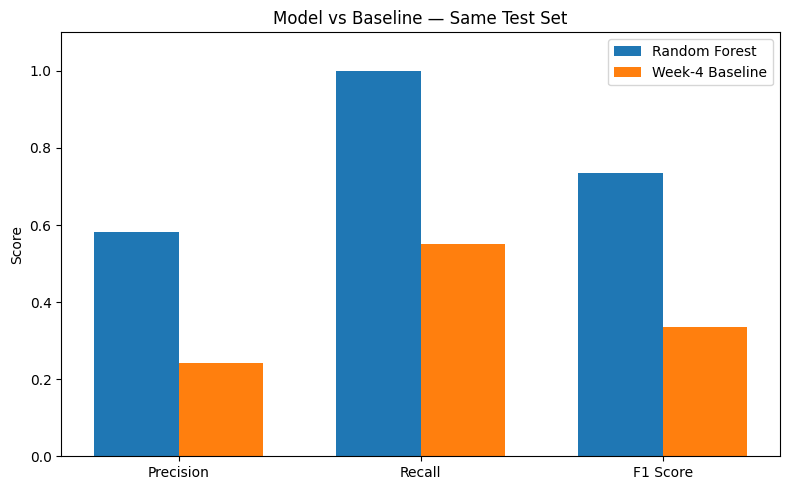

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

metrics = ["Precision", "Recall", "F1 Score"]
model_scores = [0.582, 1.000, 0.736]
baseline_scores = [0.241, 0.552, 0.336]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - width/2, model_scores, width, label="Random Forest")
ax.bar(x + width/2, baseline_scores, width, label="Week-4 Baseline")

ax.set_ylabel("Score")
ax.set_title("Model vs Baseline — Same Test Set")
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()
ax.set_ylim(0, 1.1)

plt.tight_layout()
plt.savefig("model_vs_baseline.png", dpi=150, bbox_inches="tight")
plt.show()

On the same held-out test set, the Random Forest model outperformed the
Week-4 rule-based baseline across all measured metrics, most notably in
recall (1.000 vs 0.552) — meaning the model successfully flagged all pages
that actually declined in the test set, whereas the baseline rule missed
nearly half of them. The trade-off is a moderate precision (0.582), meaning
some flagged pages did not decline — a limitation discussed in the next section.

## 5. Limitations

*What this work cannot claim.*

## Limitations

- **Single time window**: The model was trained and tested only on the
  March→April window. Out-of-time validation on additional months
  (April→May, May→June) was not completed due to compute constraints, so
  performance stability across other time periods is unverified.

- **Missing-value handling**: CTR and average position were missing for
  ~154,699 of 331,436 pages (no usable GSC data) and were filled with 0.
  A filled value of 0 does not mean an actual position of 0 — it represents
  "unavailable," and this simplification may bias predictions for those pages.

- **Label definition is narrow**: "Future decline" is defined purely by a
  ≥30% drop in clicks month-over-month. It does not account for seasonality,
  external traffic shifts, algorithm updates, or other causes — a decline
  flagged by this label may not reflect content quality issues.

- **Low precision at scale**: While recall is perfect (1.000) on the test
  set, precision is moderate (0.582), meaning a meaningful share of flagged
  pages will not actually decline. This model is best used to prioritize
  review, not as a definitive verdict.

- **Not causal**: This model identifies pages *associated with* future
  decline risk based on historical patterns. It does not prove that any
  action taken on a flagged page will prevent decline, nor does it measure
  Google's ranking algorithm directly.

- **Class imbalance**: Only ~12% of pages were labeled as future declines.
  Class-balancing was used during training (`class_weight="balanced"`),
  but this does not eliminate the underlying rarity of the outcome.

All claims in this project should be read as **observed, directional, and
decision-support** signals — not proof of causal impact.

## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*



Using the trained model's decline-probability score, all pages are ranked
and assigned an action label. The table below shows the top priority pages
— those with the highest predicted risk **and** meaningful search visibility
(≥100 impressions), so review effort is focused where it matters most.

In [ ]:
def recommendation_reason(row):
    reasons = []
    if row["decline_probability"] >= 0.70:
        reasons.append("HIGH_PREDICTED_RISK")
    if row["impressions"] >= 100 and row["ctr"] < 2:
        reasons.append("LOW_CTR")
    if row["avg_position"] >= 40:
        reasons.append("POOR_POSITION")
    if row["ga4_sessions"] <= 1 and row["scroll_events"] <= 1:
        reasons.append("LOW_ENGAGEMENT")
    return " + ".join(reasons)

def assign_action(probability):
    if probability >= 0.70:
        return "Review urgently"
    elif probability >= 0.40:
        return "Review"
    else:
        return "Monitor"

final_recommendations = (
    features[features["impressions"] >= 100]
    .assign(
        action=lambda d: d["decline_probability"].apply(assign_action),
        reason_code=lambda d: d.apply(recommendation_reason, axis=1)
    )
    .sort_values("decline_probability", ascending=False)
    .head(20)
    .reset_index(drop=True)
)

final_recommendations[
    ["content_hash_id", "impressions", "clicks", "ctr", "avg_position",
     "decline_probability", "action", "reason_code"]
]

,content_hash_id,impressions,clicks,ctr,avg_position,decline_probability,action,reason_code
0,content_aa7e550b2447c79d,117,2,1.709402,76.325974,0.969447,Review urgently,HIGH_PREDICTED_RISK + LOW_CTR + POOR_POSITION ...
1,content_14065a655b95f382,111,2,1.801802,45.123683,0.968769,Review urgently,HIGH_PREDICTED_RISK + LOW_CTR + POOR_POSITION ...
2,content_495935ac0926c0ae,113,1,0.884956,63.739737,0.967533,Review urgently,HIGH_PREDICTED_RISK + LOW_CTR + POOR_POSITION ...
3,content_d45b9a54b5f6d495,106,1,0.943396,72.224365,0.967521,Review urgently,HIGH_PREDICTED_RISK + LOW_CTR + POOR_POSITION ...
4,content_901f176c7245767e,118,1,0.847458,72.536073,0.967379,Review urgently,HIGH_PREDICTED_RISK + LOW_CTR + POOR_POSITION ...
5,content_d2ea9d7a35920d9c,100,2,2.000000,70.907667,0.967375,Review urgently,HIGH_PREDICTED_RISK + POOR_POSITION
6,content_47140c225caf4a8c,104,1,0.961538,69.086596,0.967332,Review urgently,HIGH_PREDICTED_RISK + LOW_CTR + POOR_POSITION ...
7,content_f95bc98050e5d525,104,1,0.961538,58.918182,0.967273,Review urgently,HIGH_PREDICTED_RISK + LOW_CTR + POOR_POSITION ...
8,content_d0595f96be4923bd,104,1,0.961538,52.130108,0.967248,Review urgently,HIGH_PREDICTED_RISK + LOW_CTR + POOR_POSITION ...
9,content_a65ea175b27298d2,101,1,0.990099,53.326764,0.967234,Review urgently,HIGH_PREDICTED_RISK + LOW_CTR + POOR_POSITION ...


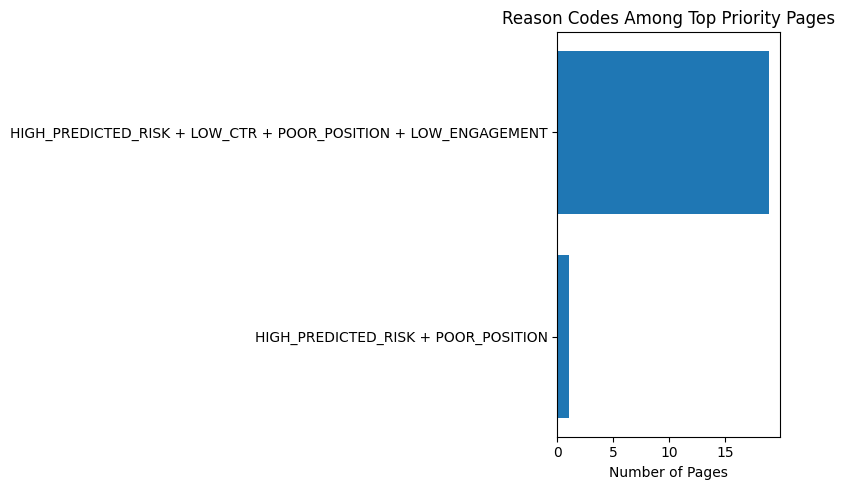

In [ ]:
import matplotlib.pyplot as plt

reason_counts = (
    final_recommendations["reason_code"]
    .value_counts()
    .sort_values(ascending=True)
)

plt.figure(figsize=(8, 5))
plt.barh(reason_counts.index, reason_counts.values)
plt.xlabel("Number of Pages")
plt.title("Reason Codes Among Top Priority Pages")
plt.tight_layout()
plt.savefig("reason_code_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

The reason codes attached to the top-priority pages show which signal(s)
triggered each flag. This breakdown helps content teams decide what kind
of review is needed — e.g. pages flagged with `LOW_CTR` likely need a
metadata/title review, while `POOR_POSITION` suggests a deeper content-quality
or backlink review.

In [ ]:
features["action"] = features["decline_probability"].apply(assign_action)
features["action"].value_counts()

,count
action,
Monitor,263432
Review urgently,67527
Review,477


Of all 331,436 scored pages, **67,527 pages (≈20%)** fall into "Review
urgently" (probability ≥ 0.70), another **477 pages** fall into "Review"
(0.40–0.70), and the remaining **263,432 pages** are in "Monitor" — no
immediate action needed. Content teams should prioritize the "Review
urgently" pages first, using the reason codes to guide what kind of review
is needed — e.g. `LOW_CTR` suggests a metadata/title review, while
`POOR_POSITION` suggests a content-quality or backlink review.

## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*


Charts and tables referenced above, collected here for the deployed paper page.

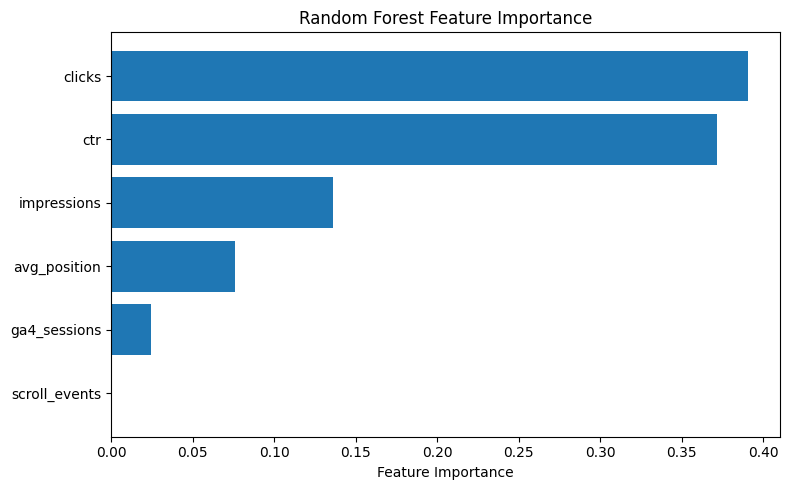

In [ ]:
import matplotlib.pyplot as plt

importance = pd.DataFrame({
    "feature": X.columns,
    "importance": model.feature_importances_
}).sort_values("importance", ascending=False)

plt.figure(figsize=(8, 5))
plt.barh(importance["feature"], importance["importance"])
plt.xlabel("Feature Importance")
plt.title("Random Forest Feature Importance")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
print("Artifacts generated for this paper:")
print("1. feature_importance.png — which signals matter most")
print("2. model_vs_baseline.png — model vs baseline comparison")
print("3. results_comparison table — precision/recall/F1/AUC")
print("4. final_recommendations table — top 20 ranked action items")
print("5. reason_code_distribution.png — why top-priority pages were flagged")

Artifacts generated for this paper:
1. feature_importance.png — which signals matter most
2. model_vs_baseline.png — model vs baseline comparison
3. results_comparison table — precision/recall/F1/AUC
4. final_recommendations table — top 20 ranked action items
5. reason_code_distribution.png — why top-priority pages were flagged


## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.